In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [36]:
df_clean = pd.read_csv('../data/processed/card_profiler_clean.csv')

In [37]:
columns_with_num = df_clean.select_dtypes(include='number').columns

In [38]:
def log1p(df, columns):
    out = np.log1p(df[columns])
    out.columns = [f"{c}_log" for c in columns]
    return out

df_prepare_clustering = log1p(df_clean, columns_with_num)
df_prepare_clustering.to_csv('../data/processed/df_prepare_clustering.csv', index=False)
df_prepare_clustering.head(5)

,BALANCE_log,PURCHASES_log,ONEOFF_PURCHASES_log,INSTALLMENTS_PURCHASES_log,CASH_ADVANCE_log,CREDIT_LIMIT_log,PAYMENTS_log
0,3.735304,4.568506,0.000000,4.568506,0.000000,6.908755,5.312231
1,8.071989,0.000000,0.000000,0.000000,8.770896,8.853808,8.319725
2,7.822504,6.651791,6.651791,0.000000,0.000000,8.922792,6.434654
3,7.419183,7.313220,7.313220,0.000000,5.331694,8.922792,0.000000
4,6.707735,2.833213,2.833213,0.000000,0.000000,7.090910,6.521114


In [39]:
pipeline = Pipeline([
    ('scaler', StandardScaler().set_output(transform='pandas')),
    ('pca', PCA().set_output(transform='pandas'))
])

In [40]:
X_pca = pipeline.fit_transform(df_prepare_clustering)

df_scaled = pipeline.named_steps['scaler'].transform(df_prepare_clustering)

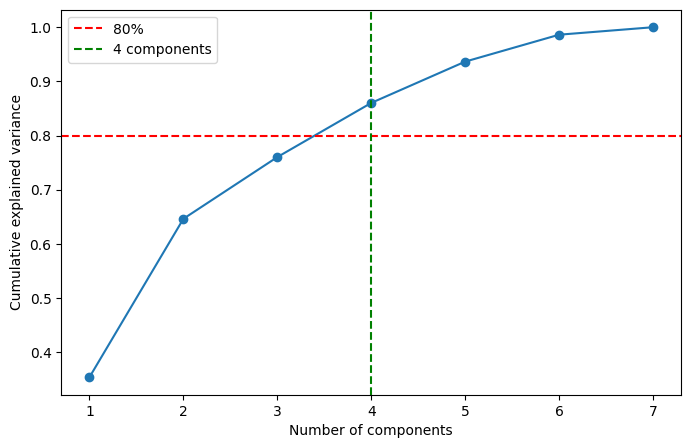

[0.354 0.293 0.114 0.1   0.076 0.05  0.014] -> n_80 = 4


In [44]:
# df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])], index=df_scaled.index)


pca = pipeline.named_steps['pca']
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_80 = np.argmax(cum_var >= 0.80) + 1

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.80, color="r", linestyle="--", label="80%")
plt.axvline(n_80, color="g", linestyle="--", label=f"{n_80} components")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.show()

print(pca.explained_variance_ratio_.round(3), "-> n_80 =", n_80)

In [45]:
skew_compare = pd.DataFrame({
    "skew_before": df_clean[columns_with_num].skew().values,
    "skew_after": df_prepare_clustering.skew().values,
}, index=columns_with_num).round(2)
skew_compare

,skew_before,skew_after
BALANCE,2.39,-0.86
PURCHASES,8.14,-0.76
ONEOFF_PURCHASES,10.04,0.19
INSTALLMENTS_PURCHASES,7.30,-0.03
CASH_ADVANCE,5.17,0.26
CREDIT_LIMIT,1.52,-0.10
PAYMENTS,5.91,-1.78


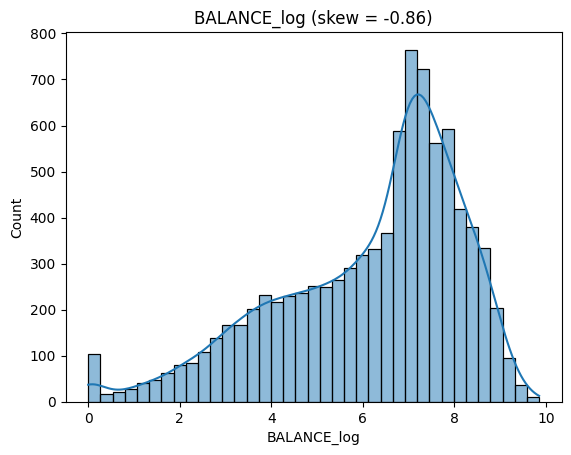

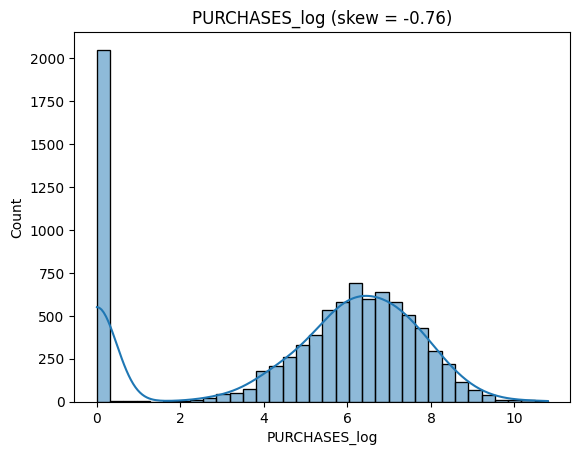

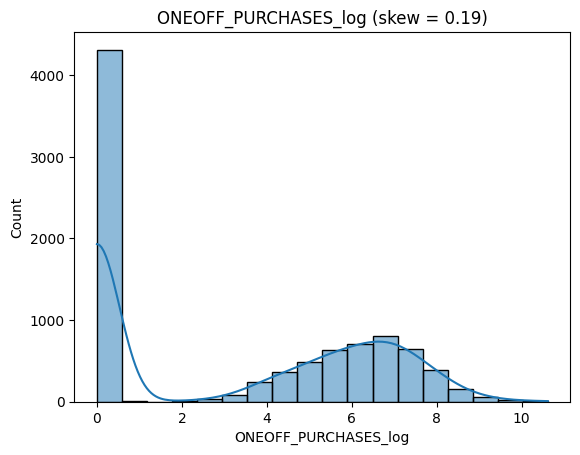

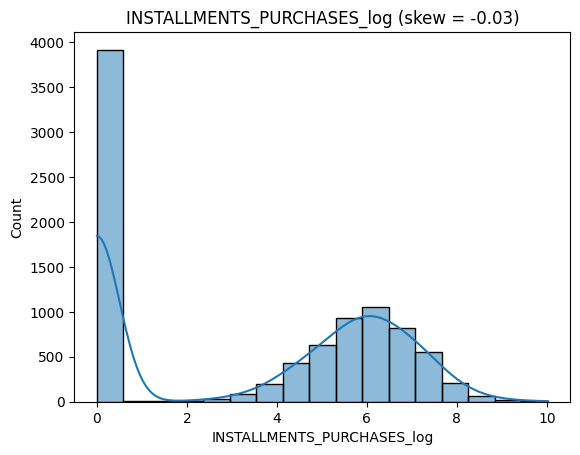

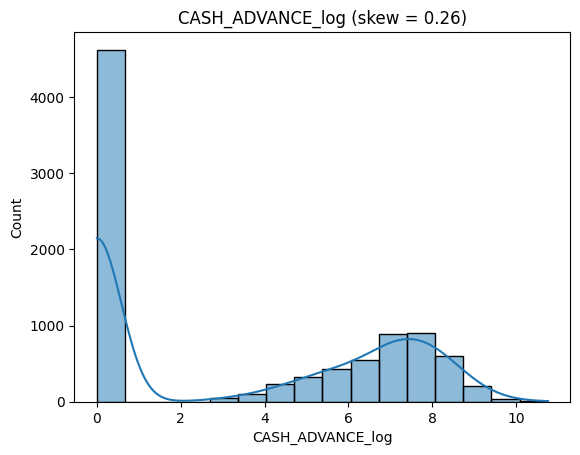

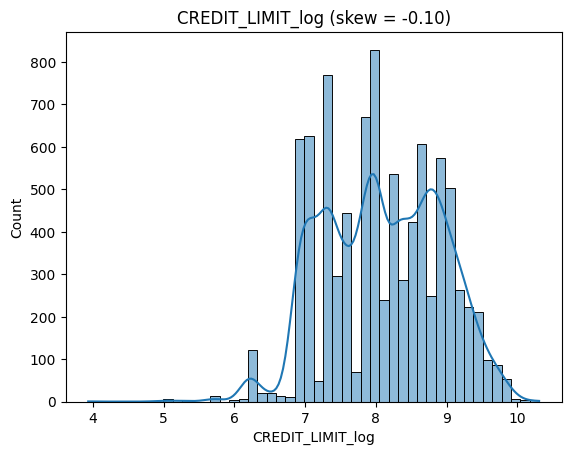

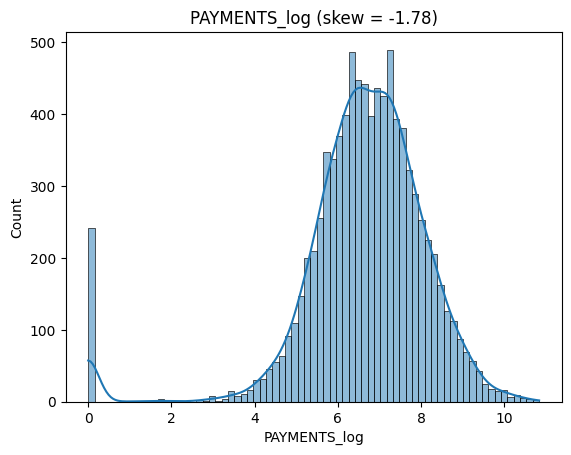

In [46]:
for col in df_prepare_clustering.columns:
    plt.figure()
    sns.histplot(df_prepare_clustering[col], kde=True)
    plt.title(f"{col} (skew = {df_prepare_clustering[col].skew():.2f})")

In [47]:
X_pca.to_csv('../data/processed/df_pca.csv', index=False)